<img src="https://udemedellin.edu.co/wp-content/uploads/2022/10/logo_udemedellin2.png" width="30%">

<b>ESPECIALIZACIÓN EN CIENCIA DE DATOS E INGELIGENCIA ARTIFICIAL</b>

<strong>Fundamentos de Estadística para Ciencia de Datos</strong>

# Sesión 2 — Estadística descriptiva de datos numéricos

## Objetivos de aprendizaje

Al finalizar esta sesión serás capaz de:

- Construir e interpretar tablas de frecuencia para una variable numérica (incluyendo la regla de Sturges).
- Calcular e interpretar medidas de tendencia central, dispersión y posición.
- Construir e interpretar histogramas y gráficos de densidad (KDE).
- Detectar valores atípicos con boxplots y compararlos con violin plots.

In [20]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="deep")
%matplotlib inline

pd.set_option("display.precision", 3)

## 1. ¿Por qué describir datos numéricos importa en ciencia de datos?

Antes de entrenar cualquier modelo, todo proyecto de ciencia de datos pasa por entender las variables con las que se están trabajando, esto con el fin de:

- **Detectar problemas de calidad de datos**: valores imposibles, escalas inconsistentes, valores atípicos asociados a errores en la captura.
- **Elegir el método correcto**: muchos modelos y pruebas estadísticas asumen ciertas condiciones (e.g. normalidad, ausencia de valores atípicos) que solo puedes verificar describiendo los datos primero.
- **Comunicar hallazgos**: muchas veces un promedio o una mediana bien elegidos resumen miles de filas en un número interpretable para alguien que no va a leer el dataset completo.
- **Ingeniería de características (feature engineering)**: decisiones como estandarizar, transformar o discretizar una variable dependen directamente de su distribución.

## 2. Tablas de frecuencia

Una tabla de frecuencias agrupa los datos en clases (intervalos) y cuenta cuántas observaciones caen en cada una. Es la versión numérica de lo que un histograma muestra visualmente (sección 3).

In [21]:
mpg = sns.load_dataset("mpg")
mpg.head(5)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [22]:
horsepower = mpg["horsepower"].dropna()
print(f"Observaciones disponibles: {len(horsepower)} de {len(mpg)} (se eliminaron {mpg['horsepower'].isna().sum()} valores faltantes)")
horsepower.describe()

Observaciones disponibles: 392 de 398 (se eliminaron 6 valores faltantes)


count    392.000
mean     104.469
std       38.491
min       46.000
25%       75.000
50%       93.500
75%      126.000
max      230.000
Name: horsepower, dtype: float64

### ¿Cuántas clases usar? → Regla de Sturges

Un número de clases mal elegido puede ocultar la forma real de los datos (muy pocas clases) o generar ruido (demasiadas clases). La **regla de Sturges** ofrece un número de clases razonable como punto de partida:

$$k = \lceil 1 + \log_{2}(n) \rceil = \lceil 1 + 3.322 \cdot \log_{10}(n) \rceil$$

dónde el operador $\lceil . \rceil$ es la función ceil (techo).

La **amplitud de clase** sugerida es:

$$A = \frac{\text{rango}}{k} = \frac{\max - \min}{k}$$

In [23]:
n = len(horsepower)
value_range = horsepower.max() - horsepower.min()
k = np.ceil(1 + 3.322 * np.log10(n))
bin_width = np.ceil(value_range / k)

print(f"n = {n}")
print(f"Rango = {value_range}")
print(f"Número de clases sugerido (Sturges): k = {k}")
print(f"Amplitud de clase sugerida: {bin_width}")

n = 392
Rango = 184.0
Número de clases sugerido (Sturges): k = 10.0
Amplitud de clase sugerida: 19.0


In [24]:
k = int(k)

lower_bound = np.floor(horsepower.min())
bin_edges = [lower_bound + i * bin_width for i in range(k + 1)]
bins_series = pd.cut(horsepower, bins=bin_edges, include_lowest=True)

# FA: Frecuencia Absoluta
# FR: Frecuencia Relativa

frequency_table = bins_series.value_counts().sort_index().to_frame(name="FA")
frequency_table["FR"] = frequency_table["FA"] / n
frequency_table["pct (%)"] = frequency_table["FR"] * 100
frequency_table["FA acumulada"] = frequency_table["FA"].cumsum()
frequency_table["FR acumulada"] = frequency_table["FR"].cumsum()
frequency_table

,FA,FR,pct (%),FA acumulada,FR acumulada
horsepower,,,,,
"(45.999, 65.0]",37,0.094,9.439,37,0.094
"(65.0, 84.0]",95,0.242,24.235,132,0.337
"(84.0, 103.0]",112,0.286,28.571,244,0.622
"(103.0, 122.0]",47,0.120,11.990,291,0.742
"(122.0, 141.0]",24,0.061,6.122,315,0.804
"(141.0, 160.0]",40,0.102,10.204,355,0.906
"(160.0, 179.0]",15,0.038,3.827,370,0.944
"(179.0, 198.0]",11,0.028,2.806,381,0.972
"(198.0, 217.0]",6,0.015,1.531,387,0.987


**Ejercicio:** construye la tabla de frecuencias (FA, FR, %, acumuladas) para la variable `weight` de `mpg`, calculando tú mismo el número de clases con la regla de Sturges.

In [6]:
# Ejercicio: tabla de frecuencias
# TODO 1: calcula n, rango, k (Sturges) y amplitud para mpg["weight"]
# TODO 2: construye las clases con pd.cut y arma la tabla de FA, FR, % y acumuladas

## 3. Histogramas y gráficos de densidad

Similar a las tablas de frecuencia, un **histograma** se construye dividiendo el rango de la variable en clases y dibujando una barra cuya altura es la frecuencia o densidad de cada clase. Recordemos que el número de clases elegido cambia mucho la lectura visual:

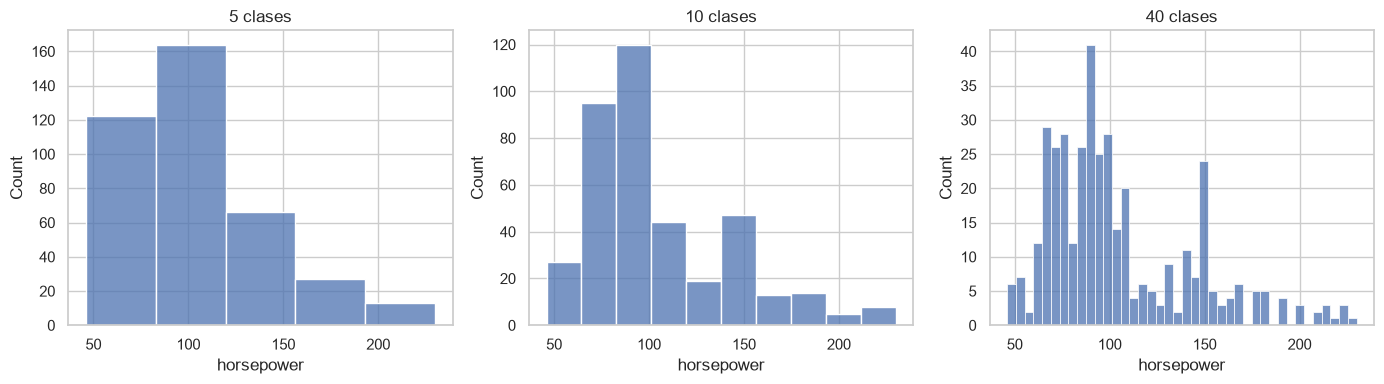

In [26]:
n = len(horsepower)
value_range = horsepower.max() - horsepower.min()
k = int(np.ceil(1 + 3.322 * np.log10(n)))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, n_bins in zip(axes, [5, k, 40]):
    sns.histplot(horsepower, bins=n_bins, ax=ax)
    ax.set_title(f"{n_bins} clases")
plt.tight_layout()
plt.show()

Muy pocas clases (izquierda) esconden detalles de la forma de los datos; demasiadas (derecha) generan ruido visual. El valor sugerido por Sturges (centro) suele ser un buen punto de partida, aún así, una inspección visual nunca está de más.

### Gráfico de densidad (KDE)

Un **KDE** (*Kernel Density Estimate*) reemplaza las barras por una curva suave: coloca una pequeña curva ("kernel", normalmente gaussiana) centrada en cada observación y las suma todas. El resultado es una estimación continua de la densidad, controlada por un parámetro de suavizado (ancho de banda) análogo al ancho de clase de un histograma.

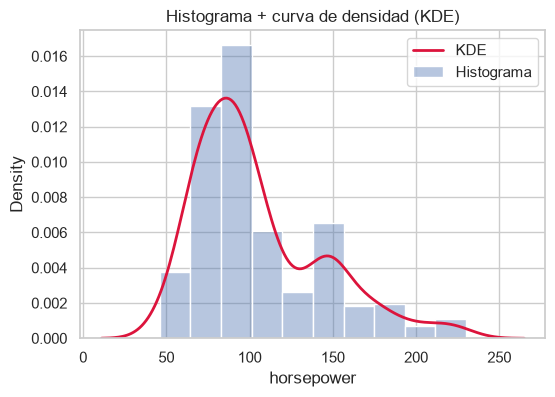

In [29]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(horsepower, stat="density", bins=k, alpha=0.4, ax=ax, label="Histograma")
sns.kdeplot(horsepower, ax=ax, color="crimson", linewidth=2, label="KDE")
ax.set_title("Histograma + curva de densidad (KDE)")
ax.legend()
plt.show()

Comparemos la forma de dos variables del mismo dataset: una "más simétrica" y otra con asimetría más notoria.

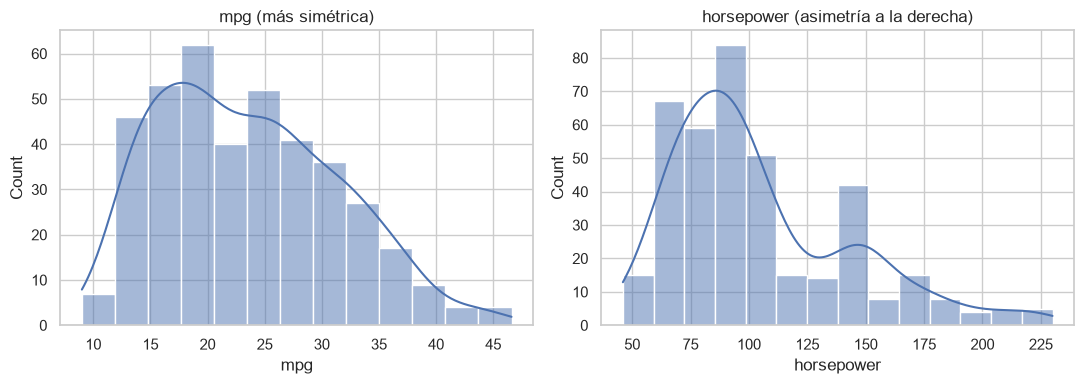

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(mpg["mpg"], kde=True, ax=axes[0])
axes[0].set_title("mpg (más simétrica)")
sns.histplot(horsepower, kde=True, ax=axes[1])
axes[1].set_title("horsepower (asimetría a la derecha)")
plt.tight_layout()
plt.show()

**Ejercicio:** grafica el histograma con KDE de `mpg["weight"]`. Con solo mirar la forma, ¿dirías que está sesgada a la izquierda, a la derecha, o es aproximadamente simétrica?

In [ ]:
# Ejercicio: histograma y densidad
# TODO: grafica sns.histplot(mpg["weight"], kde=True) e interpreta la forma

## 4. Medidas de tendencia central

Buscan resumir el "valor típico" de una variable con un único número. 

Sea $x_1, x_2, \dots, x_n$ una muestra de tamaño $n$, tenemos las siguientes definiciones:

### Media aritmética ($\bar{x}$)

$$\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$$

Se podría ver como el "centro" de los datos. Por depender de la suma de todos los valores, es **sensible** a valores atípicos, es decir, un solo valor extremo puede desplazarla notablemente.

### Mediana

Ordenando los datos como $x_{(1)} \le x_{(2)} \le \dots \le x_{(n)}$, la mediana es el valor que deja 50% de las observaciones por debajo y 50% por encima:

$$
\text{Mediana} =
\begin{cases}
x_{\left(\frac{n+1}{2}\right)} & \text{si } n \text{ es impar} \\[4pt]
\dfrac{1}{2}\left(x_{\left(\frac{n}{2}\right)} + x_{\left(\frac{n}{2}+1\right)}\right) & \text{si } n \text{ es par}
\end{cases}
$$

Al depender solo de la **posición central** y no del valor exacto de cada dato, es **robusta** a valores atípicos.

### Moda

Es el valor (o valores, si hay empate) que ocurre con mayor frecuencia. Es la única medida de tendencia central que tiene sentido para variables **cualitativas**, la categoría más común. En variables continuas puede no ser única ni informativa, rara vez se repite exactamente un valor. En tablas de frecuencias agrupadas se suele hablar de la **clase modal**, es decir, el intervalo con mayor `FA`.

| Medida | Sensible a atípicos | Aplica a cualitativas |
|---|---|---|
| Media | Sí | No |
| Mediana | No | No (requiere al menos orden, es decir ordinal o superior) |
| Moda | No | Sí |

In [7]:
mean = horsepower.mean()
median = horsepower.median()
mode = horsepower.mode()

print(f"Media: {mean:.2f}")
print(f"Mediana: {median:.2f}")
print(f"Moda: {mode.tolist()}")

Media: 104.47
Mediana: 93.50
Moda: [150.0]


Notese que la media es mayor que la mediana: es un primer indicio de **asimetría** en los datos, hacia la derecha (cola de valores altos). Profundizaremos en cómo medir la asimetría formalmente en la próxima sesión.

<figure>
  <img src="https://www.statisticshowto.com/wp-content/uploads/2014/02/pearson-mode-skewness.jpg" alt="Asimetría en datos" style="opacity: 1; max-width: 600px;">
  <figcaption style="font-size: 0.85em; color: gray;">Fuente: <a href="https://www.statisticshowto.com/probability-and-statistics/skewed-distribution/">Statistics How To</a></figcaption>
</figure>



### Otras medias (menos comunes, pero útiles)

**Media ponderada:** cuando las observaciones no deben contar igual porque cada una trae asociado un peso $w_i$ distinto:

$$\bar{x}_w = \frac{\sum_{i=1}^{n} w_i x_i}{\sum_{i=1}^{n} w_i}$$

La media aritmética es el caso particular en que todos los $w_i$ son iguales.

**Media geométrica:** para promediar cantidades que se combinan **multiplicativamente** (tasas de crecimiento, factores de retorno), no de forma aditiva:

$$\bar{x}_g = \sqrt[n]{\prod_{i=1}^{n} x_i} = \left(x_1 \, x_2 \cdots x_n\right)^{1/n}$$

Solo está definida para valores positivos. Promediar tasas de crecimiento con la media aritmética sobreestima el crecimiento acumulado real, porque ignora el efecto compuesto (cada periodo crece sobre el resultado del anterior, no sobre el valor original).

**Media armónica:** para promediar **tasas** (razones) cuando lo que se mantiene fijo es el numerador de esas tasas y lo que cambia es el denominador, un ejemplo clásico es promediar velocidades recorriendo la misma distancia en tiempos distintos:

$$\bar{x}_h = \frac{n}{\displaystyle\sum_{i=1}^{n} \frac{1}{x_i}}$$

Para un mismo conjunto de valores positivos (sin ponderar) siempre se cumple $\bar{x}_h \le \bar{x}_g \le \bar{x}$ (media armónica ≤ media geométrica ≤ media aritmética), con igualdad únicamente cuando todos los valores son iguales.

| Media | Cuándo usarla |
|---|---|
| Ponderada | Promedios donde cada observación tiene una importancia distinta |
| Geométrica | Tasas de crecimiento, retornos de inversión compuestos |
| Armónica | Promediar tasas/velocidades sobre una misma distancia o cantidad |

In [31]:
# Media ponderada: nota final con distinta ponderación por actividad
grades = np.array([4.5, 3.8, 4.0])
weights = np.array([0.5, 0.3, 0.2])
weighted_mean = np.average(grades, weights=weights)
print(f"Media ponderada: {weighted_mean:.2f}")

# Media geométrica: crecimiento promedio anual de una inversión
growth_rates = np.array([1.05, 1.12, 0.98])
geometric_mean = stats.gmean(growth_rates)
print(f"Media geométrica: {geometric_mean:.4f} (~{(geometric_mean - 1) * 100:.2f}% anual)")

# Media armónica: velocidad promedio en un trayecto ida (60 km/h) y vuelta (40 km/h)
speeds = np.array([60, 40])
harmonic_mean = stats.hmean(speeds)
print(f"Media armónica: {harmonic_mean:.2f} km/h")

Media ponderada: 4.19
Media geométrica: 1.0484 (~4.84% anual)
Media armónica: 48.00 km/h


**Ejercicio:** calcula la media, mediana y moda de `mpg["mpg"]`. Comparando media y mediana, ¿hacia qué lado esperarías que esté sesgada esta variable?

In [33]:
# Ejercicio: tendencia central
# TODO: calcula media, mediana y moda de mpg["mpg"] y compáralas

## 5. Medidas de dispersión

La tendencia central no dice nada sobre qué tan dispersos están los datos alrededor de dicho valor, por ejemplo, dos variables pueden tener la misma media y lucir muy distintas.

### Rango

$$\text{Rango} = \max(x_i) - \min(x_i)$$

La distancia entre el valor máximo y el mínimo. Al usar solo dos observaciones, ignora la forma del resto de la distribución, es muy sensible a valores atípicos.

### Varianza

- **Poblacional:**
$$\sigma^2 = \frac{\sum_{i=1}^{N} (x_i - \mu)^2}{N}$$
con $N$ el tamaño de la población y $\mu$ su media.

- **Muestral:**
$$s^2 = \frac{\sum_{i=1}^{n} (x_i - \bar{x})^2}{n - 1}$$

Promedia qué tan lejos está cada observación de la media. Las diferencias se elevan al cuadrado para evitar que la suma de las diferencias sin elevar al cuadrado de cero, $\sum (x_i - \bar{x}) = 0$ (propiedad algebraica de la media). Al elevar las diferencias al cuadrado, las diferencias grandes pesan más que proporcionalmente que las pequeñas. El resultado queda en **unidades al cuadrado** (e.g. unidad de distancia al cuadrado para la variable altura), lo que dificulta interpretarlo directamente.

En la práctica casi siempre se calcula la versión **muestral**: rara vez se tiene acceso a toda la población. Se divide entre $n-1$ en vez de $n$ porque $\bar{x}$ ya se calculó con esa misma muestra, lo que hace que $\sum(x_i - \bar{x})^2$ subestime sistemáticamente la dispersión poblacional real; dividir entre $n-1$ corrige ese sesgo (**corrección de Bessel**).

### Desviación estándar

- **Poblacional:**
$$\sigma = \sqrt{\sigma^2} = \sqrt{\frac{\sum_{i=1}^{N} (x_i - \mu)^2}{N}}$$

- **Muestral:**
$$s = \sqrt{s^2} = \sqrt{\frac{\sum_{i=1}^{n} (x_i - \bar{x})^2}{n - 1}}$$

La raíz cuadrada de la varianza. Revierte el cuadrado y devuelve el resultado a las unidades originales de la variable, por lo que es más interpretable que la varianza. Se puede interpretar como la distancia "típica" entre una observación y la media.

### Coeficiente de variación (CV)

$$CV = \frac{s}{\bar{x}}$$

Expresa la desviación estándar en comparación a la media, por lo que es **adimensional**. Esto permite comparar la dispersión relativa de dos variables en escalas o unidades distintas (p. ej. dispersión de ingresos en pesos vs. dispersión de edad en años), algo que la desviación estándar por sí sola no permite al estar atada a la unidad original.

| Medida | Unidades | Sensible a atípicos |
|---|---|---|
| Rango | Las mismas de la variable | Muy sensible (usa solo los 2 valores extremos) |
| Varianza | Unidades al cuadrado | Sí |
| Desviación estándar | Las mismas de la variable | Sí |
| Coeficiente de variación | Adimensional | Sí (hereda la sensibilidad de $s$) |

In [35]:
mean = horsepower.mean()

sample_variance = horsepower.var(ddof=1)
std_dev = horsepower.std(ddof=1)
cv = std_dev / mean * 100

print(f"Rango: {value_range:.1f}")
print(f"Varianza muestral: {sample_variance:.2f}")
print(f"Desviación estándar: {std_dev:.2f}")
print(f"Coeficiente de variación: {cv:.1f}%")

Rango: 184.0
Varianza muestral: 1481.57
Desviación estándar: 38.49
Coeficiente de variación: 36.8%


Usamos `ddof=1` porque, como vimos en la sección anterior, `horsepower` es una muestra (no tenemos los datos de todos los autos existentes), así que corresponde la fórmula muestral con la corrección de Bessel ($n-1$).

### Estandarización (z-score)

Convierte cada valor a unidades de desviaciones estándar respecto a la media, permitiendo comparar observaciones de distintas variables/escalas. Es muy usada para detección de atípicos por z-score y de muchas técnicas de *feature scaling* en machine learning:

$$z = \frac{x - \bar{x}}{s}$$

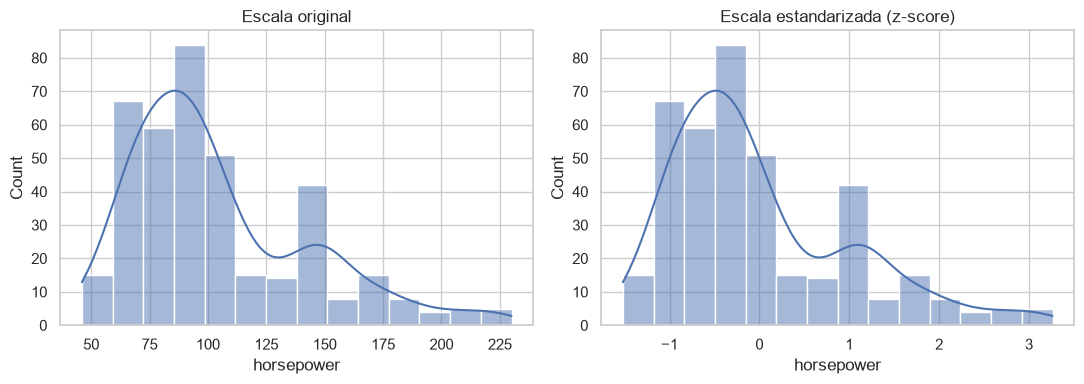

In [36]:
mean = horsepower.mean()
std_dev = horsepower.std(ddof=1)

horsepower_z = (horsepower - mean) / std_dev

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(horsepower, kde=True, ax=axes[0])
axes[0].set_title("Escala original")
sns.histplot(horsepower_z, kde=True, ax=axes[1])
axes[1].set_title("Escala estandarizada (z-score)")
plt.tight_layout()
plt.show()

### ¿Qué tan lejos de la media es "raro"? Regla empírica vs. desigualdad de Chebyshev

La conocida **regla empírica (68-95-99.7)** dice que, en una distribución **aproximadamente normal**, el 68% de los datos cae dentro de ±1 desviación estándar, el 95% dentro de ±2, y el 99.7% dentro de ±3. Veremos qué significa "aproximadamente normal" en la próxima sesión.

Para **cualquier** distribución, sin importar su forma, la **desigualdad de Chebyshev** garantiza una cota (más conservadora, pero siempre válida):

$$P(|Z| \le k) \ge 1 - \frac{1}{k^2}$$

In [41]:
for k_value in [2, 3]:
    chebyshev_bound = 1 - 1 / k_value ** 2
    observed_proportion = (horsepower_z.abs() <= k_value).mean()
    print(f"k={k_value}: Chebyshev garantiza al menos {chebyshev_bound:.1%}; en estos datos observamos {observed_proportion:.1%}")

k=2: Chebyshev garantiza al menos 75.0%; en estos datos observamos 95.7%
k=3: Chebyshev garantiza al menos 88.9%; en estos datos observamos 98.7%


**Ejercicio:** calcula la varianza, desviación estándar y coeficiente de variación de `mpg["mpg"]` y de `mpg["weight"]`. ¿Cuál de las dos variables es relativamente más dispersa (usando el CV, no la desviación estándar)?

In [13]:
# Ejercicio: dispersión
# TODO: calcula varianza, desviación estándar y CV de "mpg" y "weight", y compara sus CV

## 6. Medidas de posición: cuantiles, deciles y percentiles

Las medidas de posición (o colocación) indican dónde se ubica un valor dentro de un conjunto de datos ordenado, y permiten comparar observaciones individuales respecto al conjunto total. A diferencia de la tendencia central (sección 4) y la dispersión (sección 5), no resumen el "centro" ni qué tan esparcidos están los datos: ubican cualquier punto de interés de la distribución.

Dado $p \in [0, 1]$, el **cuantil** de orden $p$, denotado $x_p$, es el valor que deja una proporción $p$ de los datos por debajo.

Percentiles, deciles y cuartiles son cuantiles con nombres específicos para valores particulares de $p$:

| Nombre | Notación | Relación con $x_p$ | Divide los datos en |
|---|---|---|---|
| Percentil $k$ ($k = 1, \dots, 99$) | $P_k$ | $P_k = x_{k/100}$ | 100 partes |
| Decil $j$ ($j = 1, \dots, 9$) | $D_j$ | $D_j = x_{j/10} = P_{10j}$ | 10 partes |
| Cuartil $i$ ($i = 1, 2, 3$) | $Q_i$ | $Q_1 = x_{0.25}$, $Q_2 = x_{0.50}$, $Q_3 = x_{0.75}$ | 4 partes |

$x_{0.5} = P_{50} = D_5 = Q_2$ es exactamente la **mediana** que ya definimos en la sección 4.

In [42]:
quartiles = horsepower.quantile([0.25, 0.5, 0.75])
p90 = horsepower.quantile(0.90)
deciles = horsepower.quantile([i / 10 for i in range(1, 10)])

print("Cuartiles:")
print(quartiles)
print(f"\nPercentil 90: {p90:.1f}")
print("\nDeciles:")
print(deciles)

Cuartiles:
0.25     75.0
0.50     93.5
0.75    126.0
Name: horsepower, dtype: float64

Percentil 90: 157.7

Deciles:
0.1     67.0
0.2     72.0
0.3     80.0
0.4     88.0
0.5     93.5
0.6    100.0
0.7    110.0
0.8    140.0
0.9    157.7
Name: horsepower, dtype: float64


### Rango Intercuartil (IQR)

Describe la dispersión del 50% central de los datos con la mediana en el centro, es decir, es el rango de valores que está entre $Q_1$ y $Q_3$. Es la base de la regla de detección de valores atípicos que usaremos en la siguiente sección.

In [45]:
iqr = quartiles[0.75] - quartiles[0.25]
print(f"Rango intercuartílico (IQR = Q3 - Q1): {iqr:.1f}")

Rango intercuartílico (IQR = Q3 - Q1): 51.0


**Ejercicio:** calcula el percentil 10 y el percentil 90 de `horsepower`. ¿Qué porcentaje de los vehículos tiene una potencia entre esos dos valores?

In [16]:
# Ejercicio: medidas de posición
# TODO: calcula el percentil 10 y 90 de horsepower e interpreta el rango entre ambos

## 7. Valores atípicos: boxplot y violin plot

Un **valor atípico (outlier)** es una observación inusualmente alejada del resto de los datos. No siempre es un error: puede ser un caso genuinamente extremo (un exoplaneta con un periodo orbital enorme, un cliente que compra 100 veces más que el resto), y su tratamiento depende del **contexto** del problema.

La regla más común para marcarlos con base en el IQR (sección 6) es:

$$\text{atípico si } x < Q_1 - 1.5 \cdot IQR \quad \text{o} \quad x > Q_3 + 1.5 \cdot IQR$$

Existe también un método basado en z-score, marcando como atípico si $|z| > 3$; ese método asume que los datos siguen aproximadamente una distribución normal, algo que evaluaremos en la próxima sesión.

Una tercera alternativa es fijar directamente un percentil de corte, por ejemplo:

$$\text{atípico si } x < P_1 \quad \text{o} \quad x > P_{99}$$

A diferencia del IQR o el z-score (donde la cantidad de observaciones marcadas depende de la forma de la distribución), aquí decides de antemano la fracción exacta de datos que vas a tratar como atípica ($2\%$ en el ejemplo con $P_1$/$P_{99}$), sin importar cómo luzcan los datos. Se combina típicamente con dos tratamientos:

- **Recorte (trimming):** eliminar esas observaciones.
- **Capado (winsorizing):** en vez de eliminarlas, reemplazarlas por el valor del percentil de corte (p. ej. todo lo que esté por debajo de $P_1$ se sube a $P_1$), conservando el tamaño de muestra.

La elección del percentil de corte (1/99, 5/95, etc.) es una decisión de dominio/negocio no una regla estadística.

Trabajemos con el dataset `planets` (exoplanetas descubiertos), que tiene atípicos muy marcados en el periodo orbital.

In [46]:
planets = sns.load_dataset("planets")
frequent_methods = planets["method"].value_counts()
frequent_methods = frequent_methods[frequent_methods >= 20].index

filtered_planets = planets[planets["method"].isin(frequent_methods)].dropna(subset=["orbital_period"])
filtered_planets["method"].value_counts()

method
Radial Velocity    553
Transit            397
Imaging             12
Microlensing         7
Name: count, dtype: int64

In [47]:
q1 = filtered_planets["orbital_period"].quantile(0.25)
q3 = filtered_planets["orbital_period"].quantile(0.75)
planets_iqr = q3 - q1
upper_bound = q3 + 1.5 * planets_iqr

outliers = filtered_planets[filtered_planets["orbital_period"] > upper_bound]
print(f"Q1={q1:.1f} días, Q3={q3:.1f} días, IQR={planets_iqr:.1f} días")
print(f"Límite superior para atípicos: {upper_bound:.1f} días")
print(f"Valores atípicos detectados: {len(outliers)} de {len(filtered_planets)} ({len(outliers) / len(filtered_planets):.1%})")

Q1=5.4 días, Q3=501.8 días, IQR=496.4 días
Límite superior para atípicos: 1246.3 días
Valores atípicos detectados: 126 de 969 (13.0%)


### Boxplot (diagrama de caja)

El boxplot resume la tabla de posición en un solo gráfico: la caja va de Q1 a Q3 (el IQR), la línea central es la mediana, los "bigotes" llegan hasta el último punto dentro del límite de atípicos, y los puntos individuales más allá de los bigotes son los atípicos.

Dado el rango tan amplio del periodo orbital (de menos de un día a cientos de miles de días), usamos escala logarítmica en el eje para poder comparar los grupos visualmente (los cálculos de cuartiles se hicieron sobre los datos originales, sin transformar).

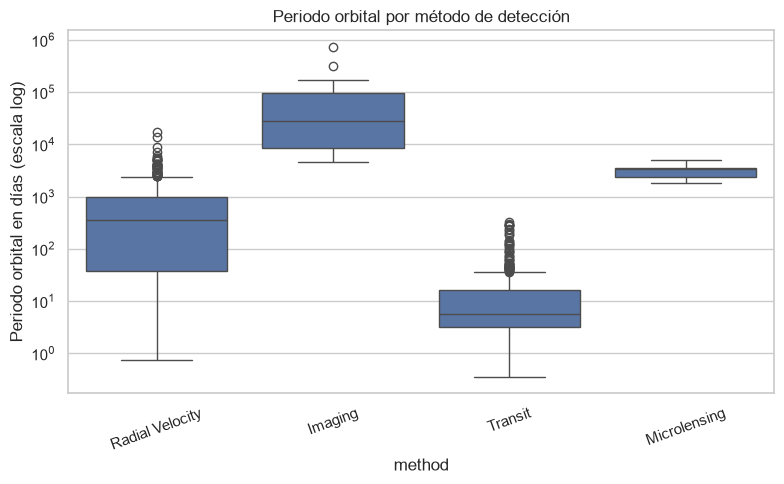

In [48]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=filtered_planets, x="method", y="orbital_period", ax=ax)
ax.set_yscale("log")
ax.set_ylabel("Periodo orbital en días (escala log)")
ax.set_title("Periodo orbital por método de detección")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Violin plot

El violin plot combina un boxplot (mediana e IQR, dibujados en el centro) con un KDE reflejado a ambos lados, mostrando la **forma completa** de la distribución (por ejemplo, si es bimodal), algo que un boxplot por sí solo no puede revelar.

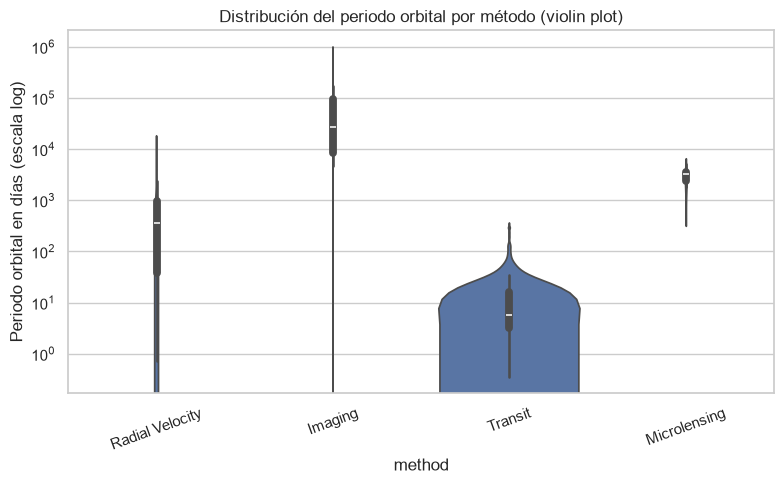

In [86]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=filtered_planets, x="method", y="orbital_period", ax=ax)
ax.set_yscale("log")
ax.set_ylabel("Periodo orbital en días (escala log)")
ax.set_title("Distribución del periodo orbital por método (violin plot)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Ejercicio:** aplica la regla del IQR a `horsepower` (sección 6 ya calculó su IQR) y determina si tiene valores atípicos. Luego grafica su boxplot con `sns.boxplot`.

In [25]:
# Ejercicio: valores atípicos
# TODO 1: calcula el límite superior de atípicos para horsepower con la regla del IQR
# TODO 2: cuenta cuántos valores de horsepower superan ese límite
# TODO 3: grafica sns.boxplot(x=horsepower)

## 8. Cierre

**Ideas clave:**

- Las tablas de frecuencia y los histogramas son dos formas (numérica y visual) de responder la misma pregunta: ¿cómo se distribuyen mis datos?
- Media, mediana y moda resumen el "centro"; rango, varianza, desviación estándar y CV resumen la "dispersión"; cuantiles/percentiles resumen la "posición relativa" de un valor.
- El boxplot y el violin plot son las dos formas visuales más comunes de detectar valores atípicos y comparar distribuciones entre grupos; el violin plot añade la forma completa de la distribución.